<a href="https://colab.research.google.com/github/tmusula/Aviation_Industry_Analysis/blob/main/Group4ProjectP4_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
import pandas as pd
import numpy as np

In [100]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import shap
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [101]:
df_crashes = pd.read_csv('/content/Refined_Traffic_Crashes_-_Crashes_20250412.csv')
df_people = pd.read_csv('/content/df_people_cleaned.csv')
df_vehicles = pd.read_csv('/content/df_vehicles_cleaned.csv')

# Data Understanding

In [102]:
df_people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2052949 entries, 0 to 2052948
Data columns (total 13 columns):
 #   Column               Dtype  
---  ------               -----  
 0   PERSON_TYPE          object 
 1   CRASH_RECORD_ID      object 
 2   SEX                  object 
 3   AGE                  float64
 4   DRIVER_ACTION        object 
 5   DRIVER_VISION        object 
 6   PHYSICAL_CONDITION   object 
 7   PEDPEDAL_ACTION      object 
 8   PEDPEDAL_VISIBILITY  object 
 9   PEDPEDAL_LOCATION    object 
 10  BAC_RESULT           object 
 11  BAC_RESULT VALUE     float64
 12  CELL_PHONE_USE       object 
dtypes: float64(2), object(11)
memory usage: 203.6+ MB


In [103]:
df_people["PERSON_TYPE"].unique()

array(['DRIVER', 'PASSENGER', 'PEDESTRIAN', 'BICYCLE',
       'NON-MOTOR VEHICLE', 'NON-CONTACT VEHICLE'], dtype=object)

In [104]:
#lets focus only on drivers, so i have filtered the driver value from the people dataframe
df_people1=df_people[df_people["PERSON_TYPE"]=="DRIVER"]

In [105]:
df_vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1906958 entries, 0 to 1906957
Data columns (total 6 columns):
 #   Column                Dtype  
---  ------                -----  
 0   CRASH_RECORD_ID       object 
 1   VEHICLE_YEAR          float64
 2   VEHICLE_DEFECT        object 
 3   VEHICLE_TYPE          object 
 4   MANEUVER              object 
 5   EXCEED_SPEED_LIMIT_I  object 
dtypes: float64(1), object(5)
memory usage: 87.3+ MB


# Data Cleaning

In [106]:
df_driver = pd.merge(df_vehicles, df_people1, on='CRASH_RECORD_ID', how='inner')

In [107]:
df_driver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3340730 entries, 0 to 3340729
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   CRASH_RECORD_ID       object 
 1   VEHICLE_YEAR          float64
 2   VEHICLE_DEFECT        object 
 3   VEHICLE_TYPE          object 
 4   MANEUVER              object 
 5   EXCEED_SPEED_LIMIT_I  object 
 6   PERSON_TYPE           object 
 7   SEX                   object 
 8   AGE                   float64
 9   DRIVER_ACTION         object 
 10  DRIVER_VISION         object 
 11  PHYSICAL_CONDITION    object 
 12  PEDPEDAL_ACTION       object 
 13  PEDPEDAL_VISIBILITY   object 
 14  PEDPEDAL_LOCATION     object 
 15  BAC_RESULT            object 
 16  BAC_RESULT VALUE      float64
 17  CELL_PHONE_USE        object 
dtypes: float64(3), object(15)
memory usage: 458.8+ MB


In [108]:
#joining the crash dataframe to the new dataframe
merged_df = pd.merge(df_crashes, df_driver, on='CRASH_RECORD_ID', how='inner')


In [109]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3337561 entries, 0 to 3337560
Data columns (total 36 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   CRASH_RECORD_ID          object 
 1   CRASH_DATE               object 
 2   POSTED_SPEED_LIMIT       int64  
 3   TRAFFIC_CONTROL_DEVICE   object 
 4   DEVICE_CONDITION         object 
 5   WEATHER_CONDITION        object 
 6   LIGHTING_CONDITION       object 
 7   FIRST_CRASH_TYPE         object 
 8   TRAFFICWAY_TYPE          object 
 9   ROADWAY_SURFACE_COND     object 
 10  ROAD_DEFECT              object 
 11  PRIM_CONTRIBUTORY_CAUSE  object 
 12  SEC_CONTRIBUTORY_CAUSE   object 
 13  BEAT_OF_OCCURRENCE       float64
 14  NUM_UNITS                int64  
 15  CRASH_HOUR               int64  
 16  CRASH_DAY_OF_WEEK        int64  
 17  CRASH_MONTH              int64  
 18  LOCATION                 object 
 19  VEHICLE_YEAR             float64
 20  VEHICLE_DEFECT           object 
 21  VEHICLE_

## Target Grouping

In [110]:
merged_df["PRIM_CONTRIBUTORY_CAUSE"].unique()

array(['FAILING TO YIELD RIGHT-OF-WAY', 'UNABLE TO DETERMINE',
       'IMPROPER TURNING/NO SIGNAL', 'DISREGARDING TRAFFIC SIGNALS',
       'IMPROPER BACKING', 'FOLLOWING TOO CLOSELY',
       'FAILING TO REDUCE SPEED TO AVOID CRASH',
       'IMPROPER OVERTAKING/PASSING', 'TURNING RIGHT ON RED',
       'IMPROPER LANE USAGE', 'NOT APPLICABLE',
       'DRIVING ON WRONG SIDE/WRONG WAY', 'DISREGARDING STOP SIGN',
       'DISREGARDING ROAD MARKINGS',
       'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER',
       'WEATHER', 'EQUIPMENT - VEHICLE CONDITION',
       'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE',
       'PHYSICAL CONDITION OF DRIVER',
       'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)',
       'EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST',
       'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)',
       'DISTRACTION - FROM INSIDE VEHICLE', 'ANIMAL',
       'DISTRACTION - FROM OUTSIDE VEHICLE',
       'CELL PHONE USE OTH

In [111]:
#changing the y to fewer levels
cause_map = {
    #  Driver Behavior
    'FOLLOWING TOO CLOSELY': 'Driver Behavior',
    'FAILING TO REDUCE SPEED TO AVOID CRASH': 'Driver Behavior',
    'IMPROPER BACKING': 'Driver Behavior',
    'IMPROPER TURNING/NO SIGNAL': 'Driver Behavior',
    'IMPROPER LANE USAGE': 'Driver Behavior',
    'IMPROPER OVERTAKING/PASSING': 'Driver Behavior',
    'DRIVING ON WRONG SIDE/WRONG WAY': 'Driver Behavior',
    'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER': 'Driver Behavior',
    'EXCEEDING AUTHORIZED SPEED LIMIT': 'Driver Behavior',
    'EXCEEDING SAFE SPEED FOR CONDITIONS': 'Driver Behavior',

    # Distraction
    'DISTRACTION - FROM INSIDE VEHICLE': 'Distraction',
    'DISTRACTION - FROM OUTSIDE VEHICLE': 'Distraction',
    'DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)': 'Distraction',
    'TEXTING': 'Distraction',
    'CELL PHONE USE OTHER THAN TEXTING': 'Distraction',

    # Traffic Rule Violations
    'FAILING TO YIELD RIGHT-OF-WAY': 'Traffic Violations',
    'DISREGARDING OTHER TRAFFIC SIGNS': 'Traffic Violations',
    'DISREGARDING TRAFFIC SIGNALS': 'Traffic Violations',
    'DISREGARDING ROAD MARKINGS': 'Traffic Violations',
    'DISREGARDING STOP SIGN': 'Traffic Violations',
    'DISREGARDING YIELD SIGN': 'Traffic Violations',
    'TURNING RIGHT ON RED': 'Traffic Violations',

    # Environmental Factors
    'WEATHER': 'Environment',
    'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)': 'Environment',
    'ROAD ENGINEERING/SURFACE/MARKING DEFECTS': 'Environment',
    'ROAD CONSTRUCTION/MAINTENANCE': 'Environment',
    'OBSTRUCTED CROSSWALKS': 'Environment',

    # Substance Use
    'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)': 'Substance Use',
    'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)': 'Substance Use',

    #Vehicle/Driver Condition
    'EQUIPMENT - VEHICLE CONDITION': 'Vehicle or Driver Condition',
    'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE': 'Vehicle or Driver Condition',
    'PHYSICAL CONDITION OF DRIVER': 'Vehicle or Driver Condition',

    #Other / Unusual Situations
    'RELATED TO BUS STOP': 'Other or Unusual',
    'PASSING STOPPED SCHOOL BUS': 'Other or Unusual',
    'EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST': 'Other or Unusual',
    'ANIMAL': 'Other or Unusual',
    'BICYCLE ADVANCING LEGALLY ON RED LIGHT': 'Other or Unusual',
    'MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT': 'Other or Unusual',

    #Unknown / Not Applicable
    'UNABLE TO DETERMINE': 'Unknown/NA',
    'NOT APPLICABLE': 'Unknown/NA'
}

# Apply the mapping
merged_df["PRIM_CONTRIBUTORY_CAUSE"]= merged_df["PRIM_CONTRIBUTORY_CAUSE"].map(cause_map)

## Missing Values

In [112]:
merged_df.isna().mean()*100

,0
CRASH_RECORD_ID,0.000000
CRASH_DATE,0.000000
POSTED_SPEED_LIMIT,0.000000
TRAFFIC_CONTROL_DEVICE,0.000000
DEVICE_CONDITION,0.000000
WEATHER_CONDITION,0.000000
LIGHTING_CONDITION,0.000000
FIRST_CRASH_TYPE,0.000000
TRAFFICWAY_TYPE,0.000000
ROADWAY_SURFACE_COND,0.000000


In [113]:
merged_df = merged_df.loc[:, merged_df.isna().mean() <= 0.9]

In [114]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3337561 entries, 0 to 3337560
Data columns (total 30 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   CRASH_RECORD_ID          object 
 1   CRASH_DATE               object 
 2   POSTED_SPEED_LIMIT       int64  
 3   TRAFFIC_CONTROL_DEVICE   object 
 4   DEVICE_CONDITION         object 
 5   WEATHER_CONDITION        object 
 6   LIGHTING_CONDITION       object 
 7   FIRST_CRASH_TYPE         object 
 8   TRAFFICWAY_TYPE          object 
 9   ROADWAY_SURFACE_COND     object 
 10  ROAD_DEFECT              object 
 11  PRIM_CONTRIBUTORY_CAUSE  object 
 12  SEC_CONTRIBUTORY_CAUSE   object 
 13  BEAT_OF_OCCURRENCE       float64
 14  NUM_UNITS                int64  
 15  CRASH_HOUR               int64  
 16  CRASH_DAY_OF_WEEK        int64  
 17  CRASH_MONTH              int64  
 18  LOCATION                 object 
 19  VEHICLE_YEAR             float64
 20  VEHICLE_DEFECT           object 
 21  VEHICLE_

In [115]:
# Delete rows where values are missing
merged_df = merged_df[~(merged_df.isnull())]

In [116]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3337561 entries, 0 to 3337560
Data columns (total 30 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   CRASH_RECORD_ID          object 
 1   CRASH_DATE               object 
 2   POSTED_SPEED_LIMIT       int64  
 3   TRAFFIC_CONTROL_DEVICE   object 
 4   DEVICE_CONDITION         object 
 5   WEATHER_CONDITION        object 
 6   LIGHTING_CONDITION       object 
 7   FIRST_CRASH_TYPE         object 
 8   TRAFFICWAY_TYPE          object 
 9   ROADWAY_SURFACE_COND     object 
 10  ROAD_DEFECT              object 
 11  PRIM_CONTRIBUTORY_CAUSE  object 
 12  SEC_CONTRIBUTORY_CAUSE   object 
 13  BEAT_OF_OCCURRENCE       float64
 14  NUM_UNITS                int64  
 15  CRASH_HOUR               int64  
 16  CRASH_DAY_OF_WEEK        int64  
 17  CRASH_MONTH              int64  
 18  LOCATION                 object 
 19  VEHICLE_YEAR             float64
 20  VEHICLE_DEFECT           object 
 21  VEHICLE_

In [117]:
merged_df.isnull().sum()

,0
CRASH_RECORD_ID,0
CRASH_DATE,0
POSTED_SPEED_LIMIT,0
TRAFFIC_CONTROL_DEVICE,0
DEVICE_CONDITION,0
WEATHER_CONDITION,0
LIGHTING_CONDITION,0
FIRST_CRASH_TYPE,0
TRAFFICWAY_TYPE,0
ROADWAY_SURFACE_COND,0


In [118]:
#fixing the datatypes so it is easier for modelling

## Feature grouping & reduction

In [119]:
merged_df['TRAFFIC_CONTROL_DEVICE'].unique()

array(['STOP SIGN/FLASHER', 'NO CONTROLS', 'TRAFFIC SIGNAL', 'UNKNOWN',
       'OTHER', 'PEDESTRIAN CROSSING SIGN', 'RR CROSSING SIGN', 'YIELD',
       'OTHER WARNING SIGN', 'OTHER REG. SIGN', 'SCHOOL ZONE',
       'RAILROAD CROSSING GATE', 'OTHER RAILROAD CROSSING',
       'FLASHING CONTROL SIGNAL', 'POLICE/FLAGMAN', 'DELINEATORS',
       'LANE USE MARKING', 'NO PASSING', 'BICYCLE CROSSING SIGN'],
      dtype=object)

In [120]:
#reducing the number of levels
control_map = {
    'PEDESTRIAN CROSSING SIGN': 'Pedestrian Control',
    'BICYCLE CROSSING SIGN': 'Pedestrian Control',
    'SCHOOL ZONE': 'Pedestrian Control',

    'RAILROAD CROSSING GATE': 'Railroad Control',
    'RR CROSSING SIGN': 'Railroad Control',
    'OTHER RAILROAD CROSSING': 'Railroad Control',

    'DELINEATORS': 'Other'
}
merged_df['TRAFFIC_CONTROL_DEVICE'] = merged_df['TRAFFIC_CONTROL_DEVICE'].map(control_map)

In [121]:
merged_df['DEVICE_CONDITION'].unique()

array(['NO CONTROLS', 'FUNCTIONING PROPERLY', 'UNKNOWN',
       'NOT FUNCTIONING', 'OTHER', 'FUNCTIONING IMPROPERLY',
       'WORN REFLECTIVE MATERIAL', 'MISSING'], dtype=object)

In [122]:
merged_df['FIRST_CRASH_TYPE'].unique()

array(['ANGLE', 'FIXED OBJECT', 'PARKED MOTOR VEHICLE', 'TURNING',
       'PEDALCYCLIST', 'REAR TO FRONT', 'SIDESWIPE OPPOSITE DIRECTION',
       'REAR END', 'SIDESWIPE SAME DIRECTION', 'HEAD ON',
       'OTHER NONCOLLISION', 'OTHER OBJECT', 'PEDESTRIAN', 'REAR TO SIDE',
       'REAR TO REAR', 'ANIMAL', 'OVERTURNED', 'TRAIN'], dtype=object)

In [123]:
crash_type_map = {
    # Vehicle-to-Vehicle
    'REAR END': 'Vehicle Collision',
    'HEAD ON': 'Vehicle Collision',
    'ANGLE': 'Vehicle Collision',
    'TURNING': 'Vehicle Collision',
    'SIDESWIPE SAME DIRECTION': 'Vehicle Collision',
    'SIDESWIPE OPPOSITE DIRECTION': 'Vehicle Collision',
    'REAR TO FRONT': 'Vehicle Collision',
    'REAR TO REAR': 'Vehicle Collision',
    'REAR TO SIDE': 'Vehicle Collision',

    # Vulnerable Road Users
    'PEDESTRIAN': 'Vulnerable User',
    'PEDALCYCLIST': 'Vulnerable User',

    # Stationary or Object
    'FIXED OBJECT': 'Fixed Object',
    'PARKED MOTOR VEHICLE': 'Fixed Object',
    'OTHER OBJECT': 'Fixed Object',
    'OTHER NONCOLLISION': 'Fixed Object',

    # Other or Special Cases
    'TRAIN': 'Special',
    'ANIMAL': 'Special',
    'OVERTURNED': 'Special'
}
merged_df['FIRST_CRASH_TYPE'] = merged_df['FIRST_CRASH_TYPE'].map(crash_type_map)

In [124]:
merged_df['TRAFFICWAY_TYPE'].unique()

array(['NOT DIVIDED', 'RAMP', 'DIVIDED - W/MEDIAN (NOT RAISED)',
       'FOUR WAY', 'DIVIDED - W/MEDIAN BARRIER', 'PARKING LOT', 'UNKNOWN',
       'OTHER', 'Y-INTERSECTION', 'ONE-WAY', 'ALLEY', 'ROUNDABOUT',
       'UNKNOWN INTERSECTION TYPE', 'T-INTERSECTION',
       'FIVE POINT, OR MORE', 'TRAFFIC ROUTE', 'NOT REPORTED', 'DRIVEWAY',
       'CENTER TURN LANE', 'L-INTERSECTION'], dtype=object)

In [125]:
intersection_map = {
    # Common intersections
    'FOUR WAY': 'Intersection',
    'T-INTERSECTION': 'Intersection',
    'Y-INTERSECTION': 'Intersection',
    'L-INTERSECTION': 'Intersection',
    'FIVE POINT, OR MORE': 'Intersection',
    'ROUNDABOUT': 'Intersection',

    # Divided roads
    'DIVIDED - W/MEDIAN BARRIER': 'Divided Road',
    'DIVIDED - W/MEDIAN (NOT RAISED)': 'Divided Road',

    # Non-divided
    'NOT DIVIDED': 'Undivided Road',
    'ONE-WAY': 'Undivided Road',
    'CENTER TURN LANE': 'Undivided Road',

    # Special or non-road spaces
    'PARKING LOT': 'Other Road Environment',
    'RAMP': 'Other Road Environment',
    'ALLEY': 'Other Road Environment',
    'DRIVEWAY': 'Other Road Environment',
    'TRAFFIC ROUTE': 'Other Road Environment',

    # Unknowns & misc
    'UNKNOWN': 'Unknown',
    'UNKNOWN INTERSECTION TYPE': 'Unknown',
    'NOT REPORTED': 'Unknown',
    'OTHER': 'Other'
}
merged_df['TRAFFICWAY_TYPE'] = merged_df['TRAFFICWAY_TYPE'].map(intersection_map)

In [126]:
merged_df['SEX'].unique()
merged_df['SEX'] = merged_df['SEX'].replace('X', 'Unspecified')

In [127]:
merged_df['DRIVER_ACTION'].unique()

array(['FAILED TO YIELD', 'NONE', 'UNKNOWN', 'IMPROPER TURN',
       'IMPROPER BACKING', 'DISREGARDED CONTROL DEVICES',
       'FOLLOWED TOO CLOSELY', 'IMPROPER PARKING', 'OTHER',
       'OVERCORRECTED', 'IMPROPER LANE CHANGE', 'WRONG WAY/SIDE',
       'IMPROPER PASSING', 'EVADING POLICE VEHICLE',
       'EMERGENCY VEHICLE ON CALL', 'TOO FAST FOR CONDITIONS',
       'STOPPED SCHOOL BUS', 'CELL PHONE USE OTHER THAN TEXTING',
       'TEXTING', 'LICENSE RESTRICTIONS'], dtype=object)

In [128]:
driver_action_map = {
    # Common driving violations
    'FAILED TO YIELD': 'Failure to Yield',
    'DISREGARDED CONTROL DEVICES': 'Traffic Violation',
    'WRONG WAY/SIDE': 'Traffic Violation',
    'STOPPED SCHOOL BUS': 'Traffic Violation',

    # Speed and spacing
    'TOO FAST FOR CONDITIONS': 'Unsafe Speed',
    'FOLLOWED TOO CLOSELY': 'Unsafe Speed',

    # Maneuver-related
    'IMPROPER TURN': 'Improper Maneuver',
    'IMPROPER LANE CHANGE': 'Improper Maneuver',
    'IMPROPER BACKING': 'Improper Maneuver',
    'IMPROPER PASSING': 'Improper Maneuver',
    'IMPROPER PARKING': 'Improper Maneuver',
    'OVERCORRECTED': 'Improper Maneuver',

    # Distraction
    'TEXTING': 'Distracted',
    'CELL PHONE USE OTHER THAN TEXTING': 'Distracted',

    # Legal / unusual edge cases
    'LICENSE RESTRICTIONS': 'Legal Issue',
    'EMERGENCY VEHICLE ON CALL': 'Special Vehicle Action',
    'EVADING POLICE VEHICLE': 'Evasive/Illegal Action',

    # General
    'NONE': 'None',
    'UNKNOWN': 'Unknown',
    'OTHER': 'Other'
}
merged_df['DRIVER_ACTION'] = merged_df['DRIVER_ACTION'].map(driver_action_map)

In [129]:
merged_df['DRIVER_VISION'].unique()

array(['NOT OBSCURED', 'UNKNOWN', 'PARKED VEHICLES', 'OTHER',
       'MOVING VEHICLES', 'BLINDED - SUNLIGHT', 'WINDSHIELD (WATER/ICE)',
       'SIGNBOARD', 'BUILDINGS', 'TREES, PLANTS', 'BLINDED - HEADLIGHTS',
       'BLOWING MATERIALS', 'EMBANKMENT', 'HILLCREST'], dtype=object)

In [130]:
driver_vision_map = {
    'NOT OBSCURED': 'Clear Vision',
    'UNKNOWN': 'Unknown',
    'OTHER': 'Other',

    # Light-related visibility issues
    'BLINDED - SUNLIGHT': 'Glare',
    'BLINDED - HEADLIGHTS': 'Glare',

    # Environmental/material obstruction
    'BLOWING MATERIALS': 'Environmental Obstruction',
    'WINDSHIELD (WATER/ICE)': 'Environmental Obstruction',

    # Physical/static object obstruction
    'MOVING VEHICLES': 'Vehicle Obstruction',
    'PARKED VEHICLES': 'Vehicle Obstruction',
    'HILLCREST': 'Physical Obstruction',
    'TREES, PLANTS': 'Physical Obstruction',
    'BUILDINGS': 'Physical Obstruction',
    'SIGNBOARD': 'Physical Obstruction',
    'EMBANKMENT': 'Physical Obstruction'
}
merged_df['DRIVER_VISION'] = merged_df['DRIVER_VISION'].map(driver_vision_map)

In [131]:
merged_df['BAC_RESULT'].unique()

array(['TEST NOT OFFERED', 'TEST REFUSED', 'TEST TAKEN',
       'TEST PERFORMED, RESULTS UNKNOWN'], dtype=object)

In [132]:
#joining the primary and secondary cause under one column
merged_df["PRIM_CONTRIBUTORY_CAUSE"].unique()

array(['Traffic Violations', 'Unknown/NA', 'Driver Behavior',
       'Environment', 'Vehicle or Driver Condition', 'Substance Use',
       'Other or Unusual', 'Distraction'], dtype=object)

In [133]:
merged_df["SEC_CONTRIBUTORY_CAUSE"].unique()

array(['FAILING TO YIELD RIGHT-OF-WAY', 'NOT APPLICABLE',
       'UNABLE TO DETERMINE', 'ROAD CONSTRUCTION/MAINTENANCE',
       'IMPROPER LANE USAGE', 'IMPROPER TURNING/NO SIGNAL',
       'FAILING TO REDUCE SPEED TO AVOID CRASH',
       'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE', 'WEATHER',
       'IMPROPER BACKING',
       'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER',
       'IMPROPER OVERTAKING/PASSING', 'EQUIPMENT - VEHICLE CONDITION',
       'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)',
       'FOLLOWING TOO CLOSELY', 'DISREGARDING TRAFFIC SIGNALS',
       'PHYSICAL CONDITION OF DRIVER',
       'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)',
       'DISREGARDING STOP SIGN', 'DISREGARDING ROAD MARKINGS',
       'DISREGARDING YIELD SIGN', 'DISTRACTION - FROM INSIDE VEHICLE',
       'ANIMAL', 'RELATED TO BUS STOP',
       'DISREGARDING OTHER TRAFFIC SIGNS',
       'DRIVING ON WRONG SIDE/WRONG WAY',
       'CELL PHONE USE

In [134]:
sec_cause_map = {
    'DISTRACTION - FROM INSIDE VEHICLE': 'Distraction',
    'DISTRACTION - FROM OUTSIDE VEHICLE': 'Distraction',
    'DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)': 'Distraction',
    'TEXTING': 'Distraction',
    'CELL PHONE USE OTHER THAN TEXTING': 'Distraction',
    'UNABLE TO DETERMINE': 'Unknown/NA',
    'NOT APPLICABLE': 'Unknown/NA',
    'WEATHER': 'Environment',
    'ROAD CONSTRUCTION/MAINTENANCE': 'Environment',
    'ROAD ENGINEERING/SURFACE/MARKING DEFECTS': 'Environment',
    'FAILING TO YIELD RIGHT-OF-WAY': 'Traffic Violations',
    'FAILING TO REDUCE SPEED TO AVOID CRASH': 'Traffic Violations',
    'DISREGARDING STOP SIGN': 'Traffic Violations',
    'DISREGARDING TRAFFIC SIGNALS': 'Traffic Violations',
    'DISREGARDING YIELD SIGN': 'Traffic Violations',
    'DISREGARDING ROAD MARKINGS': 'Traffic Violations',
    'DISREGARDING OTHER TRAFFIC SIGNS': 'Traffic Violations',
    'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE': 'Driver Behavior',
    'IMPROPER TURNING/NO SIGNAL': 'Driver Behavior',
    'IMPROPER OVERTAKING/PASSING': 'Driver Behavior',
    'FOLLOWING TOO CLOSELY': 'Driver Behavior',
    'IMPROPER LANE USAGE': 'Driver Behavior',
    'DRIVING ON WRONG SIDE/WRONG WAY': 'Driver Behavior',
    'IMPROPER BACKING': 'Driver Behavior',
    'EXCEEDING SAFE SPEED FOR CONDITIONS': 'Driver Behavior',
    'EXCEEDING AUTHORIZED SPEED LIMIT': 'Driver Behavior',
    'TURNING RIGHT ON RED': 'Driver Behavior',
    'PASSING STOPPED SCHOOL BUS': 'Driver Behavior',
    'EQUIPMENT - VEHICLE CONDITION': 'Vehicle or Driver Condition',
    'PHYSICAL CONDITION OF DRIVER': 'Vehicle or Driver Condition',
    'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)': 'Substance Use',
    'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)': 'Substance Use',
    'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER': 'Driver Behavior',
    'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)': 'Environment',
    'EMERGENCY VEHICLE ON CALL': 'Other or Unusual',
    'EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST': 'Other or Unusual',
    'ANIMAL': 'Other or Unusual',
    'RELATED TO BUS STOP': 'Other or Unusual',
    'BICYCLE ADVANCING LEGALLY ON RED LIGHT': 'Other or Unusual',
    'MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT': 'Other or Unusual',
    'OBSTRUCTED CROSSWALKS': 'Other or Unusual',
}
merged_df['SEC_CONTRIBUTORY_CAUSE'] = merged_df['SEC_CONTRIBUTORY_CAUSE'].map(sec_cause_map)


In [135]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3337561 entries, 0 to 3337560
Data columns (total 30 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   CRASH_RECORD_ID          object 
 1   CRASH_DATE               object 
 2   POSTED_SPEED_LIMIT       int64  
 3   TRAFFIC_CONTROL_DEVICE   object 
 4   DEVICE_CONDITION         object 
 5   WEATHER_CONDITION        object 
 6   LIGHTING_CONDITION       object 
 7   FIRST_CRASH_TYPE         object 
 8   TRAFFICWAY_TYPE          object 
 9   ROADWAY_SURFACE_COND     object 
 10  ROAD_DEFECT              object 
 11  PRIM_CONTRIBUTORY_CAUSE  object 
 12  SEC_CONTRIBUTORY_CAUSE   object 
 13  BEAT_OF_OCCURRENCE       float64
 14  NUM_UNITS                int64  
 15  CRASH_HOUR               int64  
 16  CRASH_DAY_OF_WEEK        int64  
 17  CRASH_MONTH              int64  
 18  LOCATION                 object 
 19  VEHICLE_YEAR             float64
 20  VEHICLE_DEFECT           object 
 21  VEHICLE_

In [136]:
df_clean = merged_df

In [137]:
df_clean.to_csv('output_df_clean.csv', index=False)

## Feature Selection

In [138]:
# get the numeric cols and the cat cols
num_original_columns = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
num_original_columns

Categorical columns: ['CRASH_RECORD_ID', 'CRASH_DATE', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'LOCATION', 'VEHICLE_DEFECT', 'VEHICLE_TYPE', 'MANEUVER', 'PERSON_TYPE', 'SEX', 'DRIVER_ACTION', 'DRIVER_VISION', 'PHYSICAL_CONDITION', 'BAC_RESULT']


['POSTED_SPEED_LIMIT',
 'BEAT_OF_OCCURRENCE',
 'NUM_UNITS',
 'CRASH_HOUR',
 'CRASH_DAY_OF_WEEK',
 'CRASH_MONTH',
 'VEHICLE_YEAR',
 'AGE']

In [139]:
target_col = "PRIM_CONTRIBUTORY_CAUSE"

numeric_features = num_original_columns

categorical_features = categorical_cols

final_features = numeric_features + categorical_features
df_model = df_clean[final_features + [target_col]].dropna()

# Encoding

In [140]:
from sklearn.preprocessing import LabelEncoder
encoded_df = df_model.copy()
le = LabelEncoder()

In [141]:
for col in categorical_features :
    try:
        encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))
    except Exception as e:
        print(f"Could not encode {col}: {e}")

Could not encode PRIM_CONTRIBUTORY_CAUSE: y should be a 1d array, got an array of shape (5548, 2) instead.


In [142]:
#Target and Features
X = encoded_df.drop('PRIM_CONTRIBUTORY_CAUSE', axis=1)
y = encoded_df['PRIM_CONTRIBUTORY_CAUSE']

In [143]:
# Checking for duplicates
print(df_model.columns[df_model.columns.duplicated()])

Index(['PRIM_CONTRIBUTORY_CAUSE'], dtype='object')


In [144]:
y = df_model.loc[:, 'PRIM_CONTRIBUTORY_CAUSE'].iloc[:, 0]

In [145]:
df_model.filter(like='PRIM_CONTRIBUTORY_CAUSE').head()

,PRIM_CONTRIBUTORY_CAUSE,PRIM_CONTRIBUTORY_CAUSE
736,Driver Behavior,Driver Behavior
737,Driver Behavior,Driver Behavior
738,Driver Behavior,Driver Behavior
739,Driver Behavior,Driver Behavior
1230,Driver Behavior,Driver Behavior


In [146]:
# Dropping duplicated column
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

In [147]:
# Checking class distribution
y = df_model['PRIM_CONTRIBUTORY_CAUSE']
print(y.value_counts())

PRIM_CONTRIBUTORY_CAUSE
Driver Behavior                2614
Unknown/NA                     1591
Traffic Violations              542
Vehicle or Driver Condition     430
Environment                     218
Distraction                      97
Other or Unusual                 36
Substance Use                    20
Name: count, dtype: int64


In [148]:
# Replacing low class frequency with 'other'
min_count = 10
value_counts = y.value_counts()
rare_classes = value_counts[value_counts < min_count].index
y_cleaned = y.replace(rare_classes, 'Other')
print(y_cleaned.value_counts())

PRIM_CONTRIBUTORY_CAUSE
Driver Behavior                2614
Unknown/NA                     1591
Traffic Violations              542
Vehicle or Driver Condition     430
Environment                     218
Distraction                      97
Other or Unusual                 36
Substance Use                    20
Name: count, dtype: int64


In [149]:
#Target and Features
X = encoded_df.drop('PRIM_CONTRIBUTORY_CAUSE', axis=1)
y = encoded_df['PRIM_CONTRIBUTORY_CAUSE']

In [150]:
# Checking the shape of Feature and Target
print(X.shape)
print(y_cleaned.value_counts())
print(X.head())


(5548, 29)
PRIM_CONTRIBUTORY_CAUSE
Driver Behavior                2614
Unknown/NA                     1591
Traffic Violations              542
Vehicle or Driver Condition     430
Environment                     218
Distraction                      97
Other or Unusual                 36
Substance Use                    20
Name: count, dtype: int64
      POSTED_SPEED_LIMIT  BEAT_OF_OCCURRENCE  NUM_UNITS  CRASH_HOUR  \
736                   30              1034.0          2          15   
737                   30              1034.0          2          15   
738                   30              1034.0          2          15   
739                   30              1034.0          2          15   
1230                  35               532.0          2          16   

      CRASH_DAY_OF_WEEK  CRASH_MONTH  VEHICLE_YEAR   AGE  CRASH_RECORD_ID  \
736                   2            2        2016.0  23.0              618   
737                   2            2        2016.0  51.0              

In [151]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cleaned,
    test_size=0.2,
    stratify=y_cleaned,
    random_state=42
)


In [152]:
#Scale Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

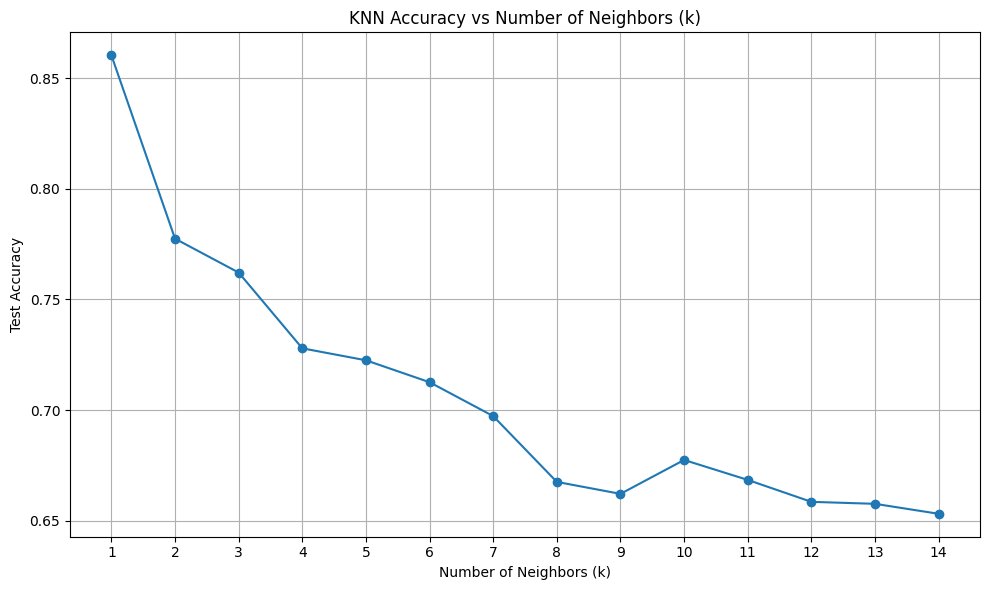

In [153]:
# Training and tuning KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Testing values of k
k_values = range(1, 15)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

In [154]:
# Finding the best k and the final model

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best k = {best_k} with accuracy = {max(accuracies):.2f}")

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

Best k = 1 with accuracy = 0.86


KNeighborsClassifier(n_neighbors=1)

In [155]:
# Tuning more hyperparameters for improvement

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Use best model on test set
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'n_neighbors': 1, 'weights': 'uniform'}
Best CV Accuracy: 0.8125288196877826
Test Accuracy: 0.8603603603603603


In [156]:
# Further improvement using PCA. Retaining 95% variance

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original shape: {X_train_scaled.shape}")
print(f"PCA-reduced shape: {X_train_pca.shape}")


Original shape: (4438, 29)
PCA-reduced shape: (4438, 24)


In [157]:
# Training on PCA transformed data

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_pca = KNeighborsClassifier(n_neighbors=1)
knn_pca.fit(X_train_pca, y_train)

y_pred_pca = knn_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
print(f"Test Accuracy with PCA: {acc_pca:.4f}")

Test Accuracy with PCA: 0.8721


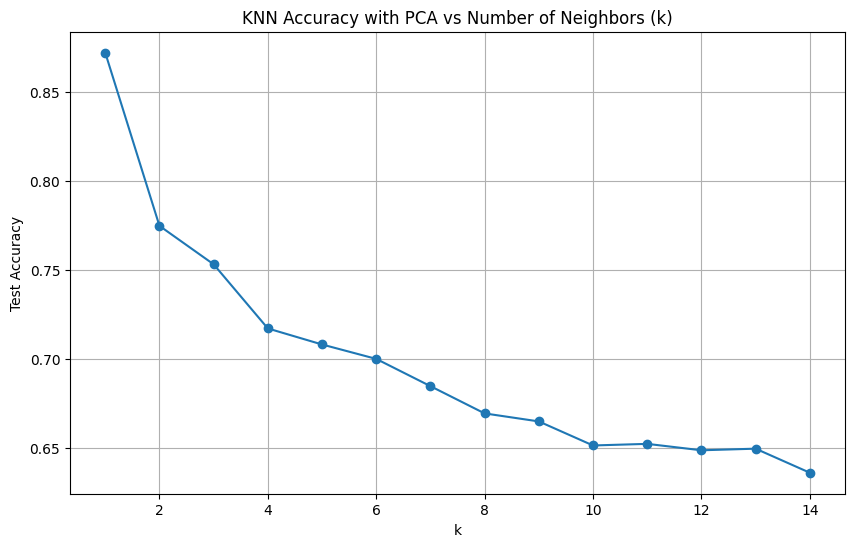

In [158]:
# Tuning on PCA transformed data

k_values = range(1, 15)
accuracies_pca = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    accuracies_pca.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies_pca, marker='o')
plt.title('KNN Accuracy with PCA vs Number of Neighbors (k)')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

In [159]:
# Finding the best fit from PCA trained data

best_k_pca = k_values[accuracies_pca.index(max(accuracies_pca))]
print(f"Best k = {best_k_pca} with accuracy = {max(accuracies_pca):.2f}")


Best k = 1 with accuracy = 0.87


In [160]:
# Trying different k value

knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_train_pca, y_train)
y_pred_3 = knn_3.predict(X_test_pca)

print("Test Accuracy with k=3:", accuracy_score(y_test, y_pred_3))

Test Accuracy with k=3: 0.7531531531531531


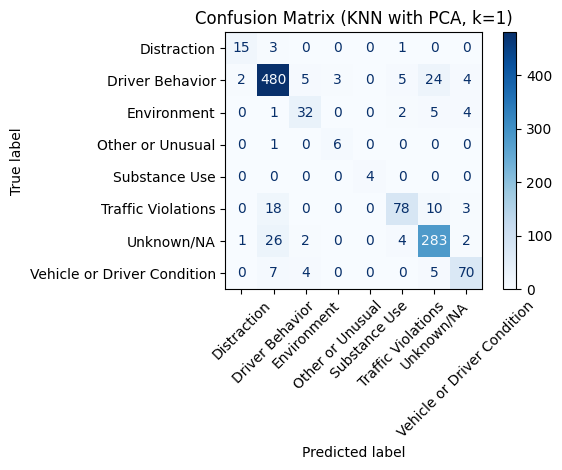

In [161]:
# Generating confusion matrix and classification report

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
y_pred_pca = knn_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_pca, labels=best_knn.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (KNN with PCA, k=1)")
plt.tight_layout()
plt.show()


In [162]:
# Generating the classification report

print("Classification Report:\n")
print(classification_report(y_test, y_pred_pca))

Classification Report:

                             precision    recall  f1-score   support

                Distraction       0.83      0.79      0.81        19
            Driver Behavior       0.90      0.92      0.91       523
                Environment       0.74      0.73      0.74        44
           Other or Unusual       0.67      0.86      0.75         7
              Substance Use       1.00      1.00      1.00         4
         Traffic Violations       0.87      0.72      0.78       109
                 Unknown/NA       0.87      0.89      0.88       318
Vehicle or Driver Condition       0.84      0.81      0.83        86

                   accuracy                           0.87      1110
                  macro avg       0.84      0.84      0.84      1110
               weighted avg       0.87      0.87      0.87      1110



# Conclusion
Precison score -  all the times the model predicted a class, how many times was it correct?
Recall - of all the actual cases of a class, how many did the model correctly identify
F1-score - it is the harmonic mean of precision and recall.
It balances both how many relevant results are found and how accurate the positive predictions.

From our model, we inference that;
The model accurately predicted 79% of the test instances.
Driver behavior has very strong performance with a recall of 90% implying most correct cases captured.
Traffic violations has a perfect recall at 1.00

